In [4]:
#6

#1
import pandas as pd

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],
    }
)
sales


#Mostrami le vendite maggiori di 10
maggiori_10 = sales[sales['sales'] > 10]
maggiori_10
#Mostrami i dati del 2018
dati_2018 = sales[sales['year'] == 2018]
dati_2018
#Mostrami le vendite maggiori di 13 e l'anno è il 2018
entrambi_18_2018 = sales[((sales['sales'] > 13) & (sales['year'] == 2018))]
#Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018
non_entrambi_13_2018 = sales[~((sales['sales'] > 13) & (sales['year'] == 2018))]
non_entrambi_13_2018
#Mostrami i dati dove le vendite divise per 3 sono maggiori di 3
vendite_divise_maggiori = sales[(sales['sales'] / 3) > 3]
vendite_divise_maggiori
#Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J
sales.query('employee > "J"')

,employee,sales,year
0,Katrina,14,2018
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019


<Axes: title={'center': 'Vendite per regione per genere'}, xlabel='Genre', ylabel='Milioni di unità'>

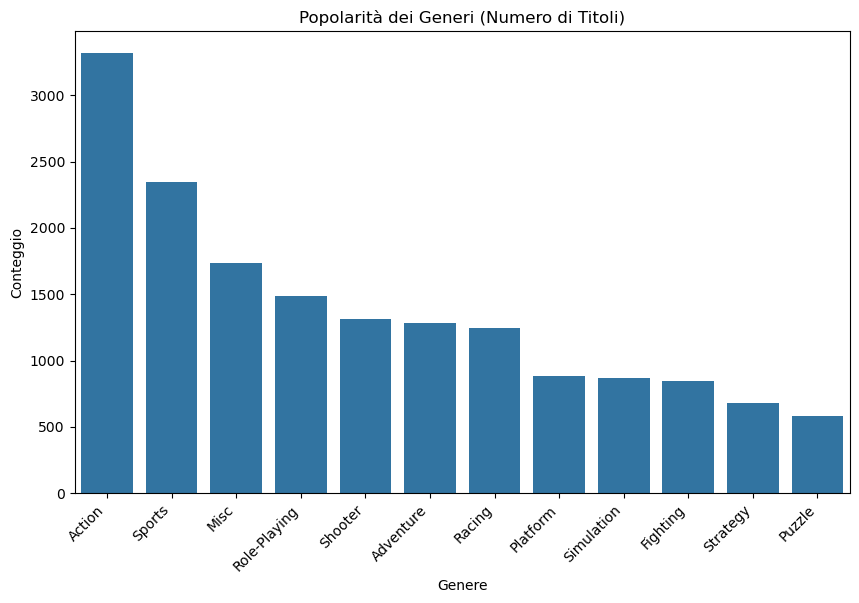

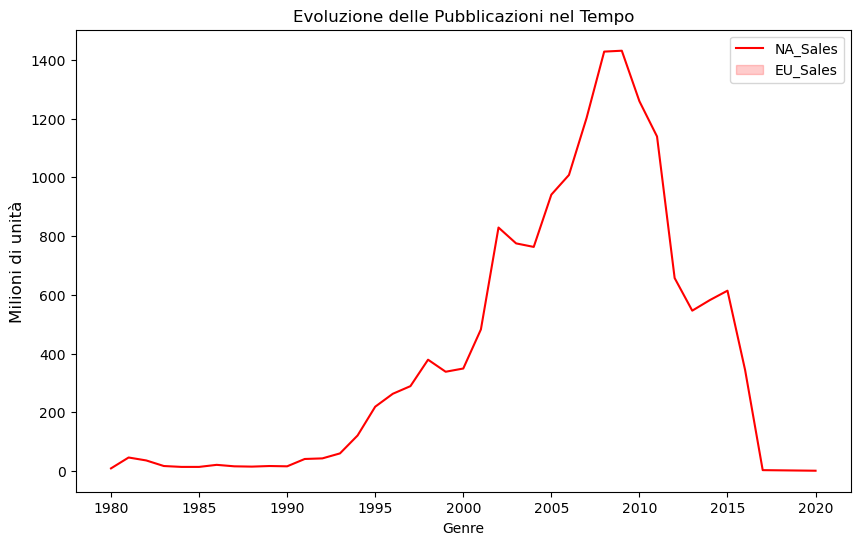

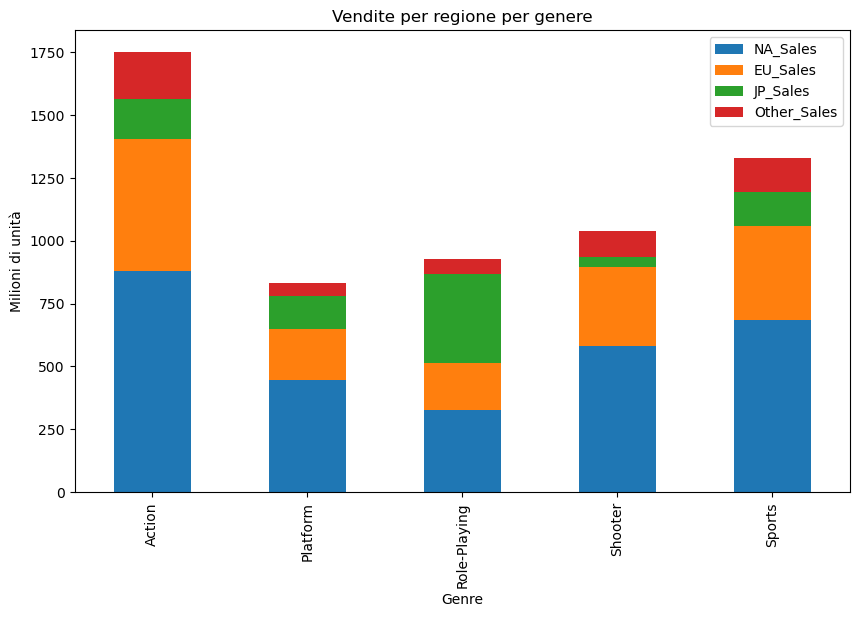

In [28]:
#2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)
df.head()

#Quanti videogiochi sono stati pubblicati
numero_giochi = len(df)
numero_giochi
#Quali sono i generi più popolari? Mostralo con un bar plot
plt.figure(figsize=(10, 6))
generi = df['Genre'].value_counts()
sns.barplot(x=generi.index, y=generi.values)
plt.title('Popolarità dei Generi (Numero di Titoli)')
plt.xlabel('Genere')
plt.ylabel('Conteggio')
plt.xticks(rotation=45, ha='right')
#Plotta l'evoluzione del numero di giochi pubblicati nel tempo
plt.figure(figsize=(10, 6))
tempo = df.groupby('Year').size()
sns.lineplot(x=tempo.index, y=tempo.values, color='red')
plt.title('Evoluzione delle Pubblicazioni nel Tempo')
plt.xlabel('Anno')
plt.ylabel('Giochi Pubblicati')

#Prova a riprodurre questo plot
plt.xlabel('Genre')
plt.ylabel('Milioni di unità', fontsize=12)
plt.legend(['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'], loc='upper right')
vendite_per_genere = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
vendite_per_genere['Total'] = vendite_per_genere.sum(axis=1)
vendite_per_genere = vendite_per_genere.sort_values('Total', ascending=False).head(5)
vendite_per_genere = vendite_per_genere.sort_index()
vendite_per_genere = vendite_per_genere.drop('Total', axis=1)
vendite_per_genere.plot(kind='bar', ylabel='Milioni di unità', title='Vendite per regione per genere', stacked=True, figsize=(10, 6))
